In [1]:
import os, sys, pickle
%pylab inline
from importlib import reload
import pandas as pd
plt.style.use('default')
plt.rcParams['figure.figsize'] = (8, 3)
from tqdm import tqdm
from copy import deepcopy
import pickle
from collections import Counter

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
git_path = os.getenv("GIT")
proj_path = os.path.join(git_path, "glom-io-transform-release")
sys.path.append(proj_path)
os.chdir(proj_path + "/model-fitting")
os.getcwd()
os.environ["GLOM_IO"] = proj_path
os.environ["GLOM_IO_DATA"] = proj_path + "/data"

In [3]:
from odours import odours
import driver; reload(driver)
from driver import RunResults

# Figure for the Paper

In [4]:
def vld_fun_ratio(vld):
    in_out = np.mean((vld.Cin - vld.Cstar)**2)**0.5
    est_out=np.mean((vld.Cest - vld.Cstar)**2)**0.5
    return in_out, est_out 

def vld_fun_corr(corrs):
    in_out = np.mean((corrs["Cin"] - corrs["Cstar"])**2)**0.5
    est_out=np.mean((corrs["Cest"] - corrs["Cstar"])**2)**0.5
    return in_out, est_out

def compute_corr_energ_(C):
    # If C is a square matrix, use the off-diagonal elements to compute the energy
    if C.shape[0] == C.shape[1]:
        total_energy = np.sum(C**2) - np.sum(np.diag(C)**2)
        n_elements = C.shape[0] * (C.shape[0] - 1)
        return total_energy / n_elements
    else:
        # If C is not square, compute the energy using all elements
        return np.mean(C**2)
        
def vld_fun_corr_energy(corrs):
    [in_, out_, est_] = [compute_corr_energ_(corrs[key]) for key in ["Cin", "Cstar", "Cest"]]
    return in_, out_, est_

In [5]:
import layout; reload(layout)
import results; reload(results)
selection_metric = "ratio"
splits = [
    ("trials", "random", "max"),
    ("odours", "random", "max"),
    ("odours", "inclass", "max"),
    ("odours", "outclass", "max")
] 
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)

## Load the covariance metric dataframe

In [6]:
which_models = ["Diag", "DiagOnlyInh", "Free", "FreeLat"]
compute_df = False
if compute_df:
    # Import cartesiaon product
    from itertools import product
    selection_metric = "ratio"
    records = []
    for split_name in splits:
        split = base.split(*split_name)
        for model_name in which_models:
            model   = split.model(model_name)
            n_train = len(model.df["ref"].unique())
            #report  = model.report(metric=selection_metric, extra_fields = ["outclass"] if "outclass" in split_name else [])     
            n_seeds = len(model.df["seed"].unique())
            # I wanted to use report to get the best parameter values, but extract already does that.
            # All in need to know is whether to include the outclass
            outclasses = model.df["outclass"].unique()
            iterable = product(range(n_seeds), range(n_train), outclasses)
            for seed, train, outclass in tqdm(iterable, total=n_seeds*n_train*len(outclasses)):
                extra_fields = {"outclass":outclass} if "outclass" in split_name else {}
                #print(f"{split_name}, {model_name}, seed={seed}, train={train}, outclass={outclass}")
                res = model.extract(seed=seed, train=train, la="min" if model_name.startswith("Diag") else None, metric=selection_metric, **extra_fields)
                cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
                corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
                corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)
                records.append({
                    "sampler": split_name[0],
                    "mode": split_name[1],
                    "n_od_train": split_name[2],
                    "model": model_name,
                    "seed": seed,
                    "train": train,
                    "outclass": outclass,
                    "cov_in_out": cov_in_out,
                    "cov_est_out": cov_est_out,
                    "corr_in_out": corr_in_out,
                    "corr_est_out": corr_est_out,
                    "corr_en_in": corr_en_in,
                    "corr_en_out": corr_en_out,
                    "corr_en_est": corr_en_est
                })
    df = pd.DataFrame(records)
    # Save the df to disk
    with open(proj_path + "/model-fitting/generalization_results.pkl", "wb") as f:
        pickle.dump(df, f)


In [17]:
# Save the df to disk
with open(proj_path + "/model-fitting/generalization_results.pkl", "rb") as f:
    df = pickle.load(f)

In [18]:
df.head()

,sampler,mode,n_od_train,model,seed,train,outclass,cov_in_out,cov_est_out,corr_in_out,corr_est_out,corr_en_in,corr_en_out,corr_en_est
0,trials,random,max,Diag,0,0,None,55.804779,27.100118,0.304090,0.175526,0.268415,0.079588,0.102576
1,trials,random,max,Diag,0,1,None,56.364182,28.232228,0.304578,0.177283,0.268415,0.080531,0.102576
2,trials,random,max,Diag,0,2,None,56.652894,28.228552,0.306596,0.178066,0.268415,0.078880,0.102576
3,trials,random,max,Diag,0,3,None,56.039460,27.652558,0.305300,0.176380,0.268415,0.080032,0.102576
4,trials,random,max,Diag,0,4,None,55.703823,27.416923,0.305495,0.177980,0.268415,0.080832,0.102576


In [19]:
df["model"].unique()

array(['Diag', 'DiagOnlyInh', 'Free', 'FreeLat'], dtype=object)

## Plot covariance metrics

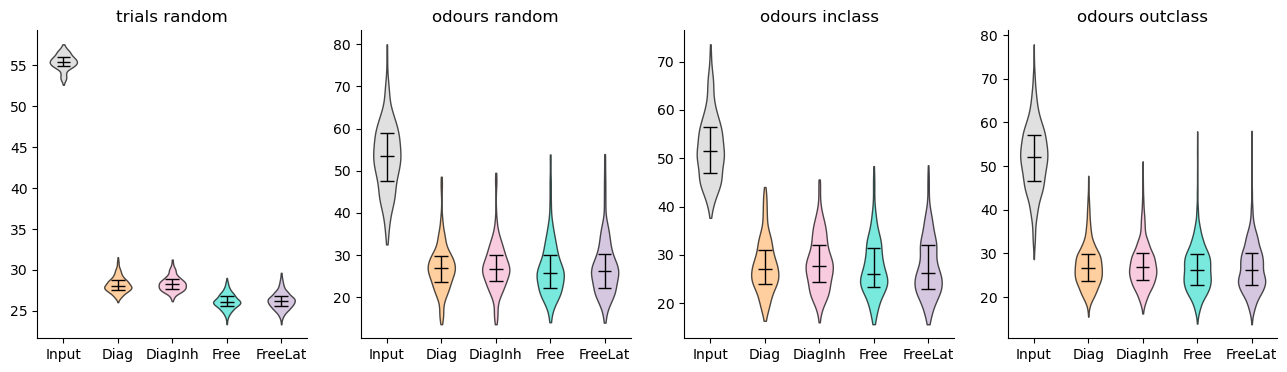

In [20]:
import figures; reload(figures)
from figures import ViolinPlotData, violin_plots, scatter_plot
import proc_fit_models as pfm; reload(pfm)
prefix = "cov"
assert prefix in ["cov", "corr", "corr_en"], "prefix must be one of 'cov', 'corr', or 'corr_en'"
nr, nc = 1, 4
fig, ax = plt.subplots(nrows=nr, ncols=nc, figsize=((4+ 0.5*(prefix=="corr_en")) * nc, 4 * nr))
split_descr = {"trials": ("trials", "random"),
               "odours_random,": ("odours", "random"),
               "odours_inclass": ("odours", "inclass"),
               "odours_outclass": ("odours", "outclass")}
order = ["trials", "odours_random,", "odours_inclass", "odours_outclass"]
model_labs = {"Diag": "Diag",
              "DiagOnlyInh": "DiagInh",
              "Free": "Free",
              "FreeLat": "FreeLat"}
model_names = list(model_labs.keys())
which_models = list(model_labs.keys())
cols = ["Gray"] + [pfm.model_color(m) for m in model_names] 
for i, (axi, split_name) in enumerate(zip(ax.flatten(), order)):
    sampler, mode = split_descr[split_name]
    split_mask = (df["sampler"] == sampler) & (df["mode"] == mode) 
    if prefix in ["cov", "corr"]:
        in_out       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in_out"].values
        models_est_out = [df[split_mask & (df['model']==m)][f"{prefix}_est_out"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(in_out, "LightGray", "Input")] + [ViolinPlotData(models_est_out[i], pfm.model_color(model_names[i]), model_labs[model_names[i]]) for i in range(len(model_names))])
    else:
        en_in       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in"].values
        en_out      = df[split_mask & (df['model']=="Diag")][f"{prefix}_out"].values
        en_est_models = [df[split_mask & (df['model']==m)][f"{prefix}_est"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(en_in, "LightGray", "Input")] + [ViolinPlotData(en_est_models[i], pfm.model_color(model_names[i]), model_labs[model_names[i]]) for i in range(len(model_names))] + [ViolinPlotData(en_out, "Gray", "Output")])
        axi.set_ylim((0, 0.45))
    axi.set_title(f"{sampler} {mode}")
    #i >0 and axi.set_ylim((0, 0.5) if prefix=="corr" else (0, 80))
    [axi.spines[spine].set_visible(False) for spine in ['top', 'right']]

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=random/n_od_train=max/loaded_models.p.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=inclass/n_od_train=max/loaded_models.p.
Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=outclass/n_od_train=max/loaded_models.p.


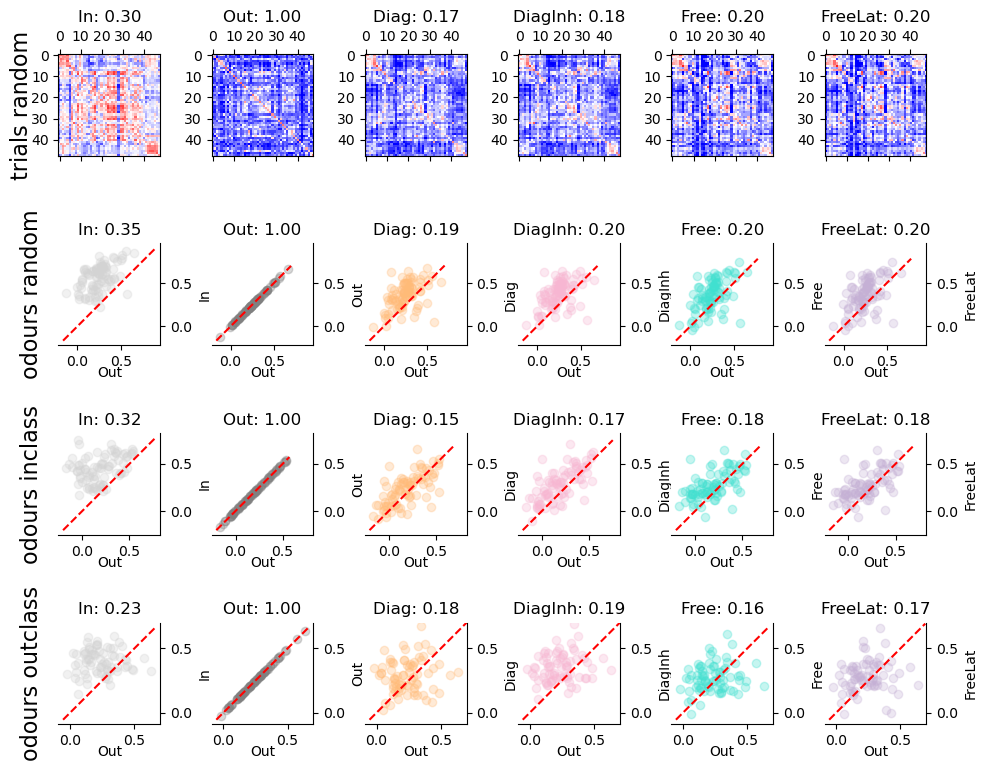

In [218]:
reload(figures)
from figures import scatter_plot
fig, ax = plt.subplots(nrows=4, ncols=len(which_models)+2, figsize=(10, 8))
vmin = {"cov": None, "corr": 0, "corr_en": 0}
vmax = {"cov": None, "corr": 1, "corr_en": 1}
cmap = {"cov": "viridis", "corr": "bwr", "corr_en": "bwr"}
ttls = ["In", "Out"] + [model_labs[m] for m in which_models]
append_to_title = lambda ax, s: ax.set_title(ax.get_title() + s)
prepend_to_title = lambda ax, s: ax.set_title(s + ax.get_title())
for i, split_name in enumerate(order):
    descr = split_descr[split_name]
    split = base.split(sampler=descr[0], mode=descr[1], n_od_train="max")
    extra_fields = {"outclass":"Ketone"} if "outclass" in split_name else {}
    for j, name in enumerate(which_models):
        model = split.model(name)
        res = model.extract(seed=0, train=0, metric=selection_metric, **extra_fields)
        covs = {k: getattr(res.vld, k) for k in ["Cin", "Cstar", "Cest"]}
        corrs = res.vld_corrs
        cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
        corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
        corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)

        vals = covs if prefix == "cov" else corrs
        matshow_kwargs = {"vmin": vmin[prefix], "vmax": vmax[prefix], "cmap": cmap[prefix]} 
        plot_fun = lambda ax, k, ylab, c: (ax.matshow(vals[k], **matshow_kwargs), ax.set_xticks(np.arange(0,50,10)), ax.set_yticks(np.arange(0,50,10))) if i == 0 else scatter_plot(ax, vals["Cstar"], vals[k], "Out", ylab, c)

        in_val  = {"cov":cov_in_out, "corr":corr_in_out, "corr_en":corr_en_in}[prefix]
        est_val = {"cov":cov_est_out, "corr":corr_est_out, "corr_en":corr_en_est}[prefix]
        out_val = {"cov":1., "corr":1., "corr_en":corr_en_out}[prefix]

        if name == "Diag":
            plot_fun(ax[i,0], "Cin", "In", "LightGray")
            ax[i,0].set_title(f"In: {in_val:.2f}")
            plot_fun(ax[i,1], "Cstar", "Out", "Gray")
            ax[i,1].set_title(f"Out: {out_val:.2f}")

        plot_fun(ax[i,2+j], "Cest", ttls[j+2], pfm.model_color(name))
        ax[i,2+j].set_title(f"{ttls[j+2]}: {est_val:.2f}")
    if i > 0:
        # Share the x and y lims with the first plot in the row
        for j in range(2 + len(which_models)):
            ax[i,j].set_xlim(ax[i,0].get_xlim())
            ax[i,j].set_ylim(ax[i,0].get_ylim())
            ax[i,j].set_aspect('equal')
            # Turn top and right spines off
            [ax[i,j].spines[spine].set_visible(False) for spine in ['top', 'left']]

    # Put the split description on the left of the row
    ax[i,0].text(-0.25 + 0.1*(i>0), 0.5, f"{descr[0]} {descr[1]}", va='center', ha='right', 
                fontsize=16, transform=ax[i,0].transAxes, rotation=90)
tight_layout(w_pad=0, h_pad=0)


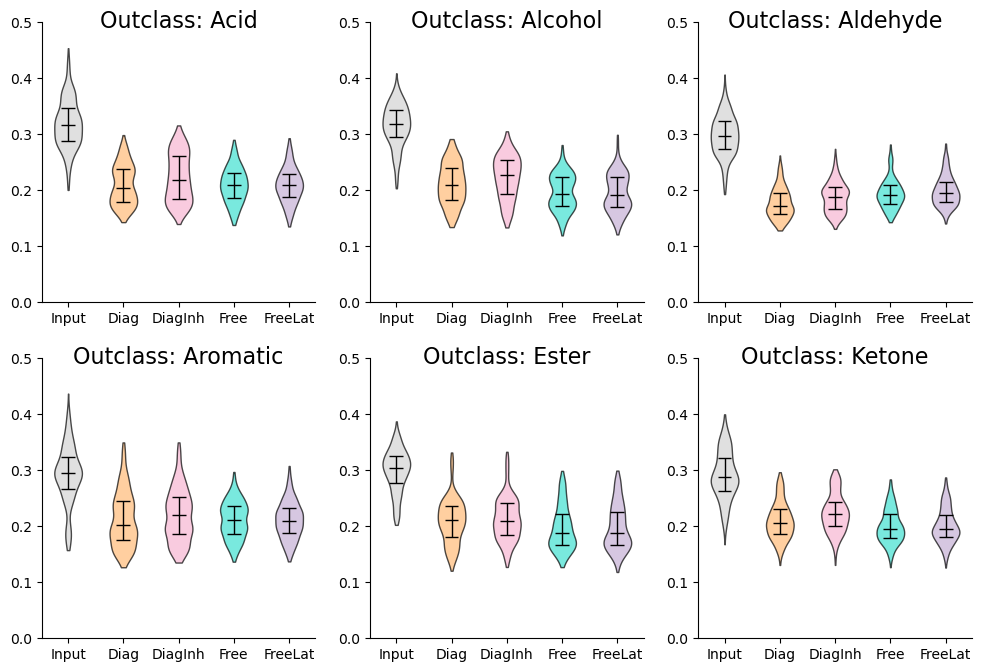

In [54]:
# Now just look at outclass, by outclass
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
outclasses = sorted(df[df.outclass.notnull()]["outclass"].unique())
for i, (axi, outclass) in enumerate(zip(ax.flatten(), outclasses)):
    split_mask = (df["sampler"] == "odours") & (df["mode"] == "outclass") & (df["outclass"] == outclass)

    if prefix in ["cov", "corr"]:
        in_out       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in_out"].values
        models_est_out = [df[split_mask & (df['model']==m)][f"{prefix}_est_out"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(in_out, "LightGray", "Input")] + [ViolinPlotData(est_out, pfm.model_color(m), model_labs[m]) for est_out, m in zip(models_est_out, model_names)])
    else:
        en_in       = df[split_mask & (df['model']=="Diag")][f"{prefix}_in"].values
        en_out      = df[split_mask & (df['model']=="Diag")][f"{prefix}_out"].values
        en_models   = [df[split_mask & (df['model']==m)][f"{prefix}_est"].values for m in model_names]
        axi = violin_plots(axi, [ViolinPlotData(en_in, "LightGray", "Input")] + [ViolinPlotData(est, pfm.model_color(m), model_labs[m]) for est, m in zip(en_models, model_names)] + [ViolinPlotData(en_out, "Gray", "Output")])
        #axi.set_ylim((0, 0.45))

    axi.set_title(f"Outclass: {outclass}", fontsize=16, y=0.95)
    axi.set_ylim((0, 0.5) if prefix in["corr", "corr_en"] else (0, 80))
    [axi.spines[spine].set_visible(False) for spine in ['top', 'right']]

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=odours/mode=outclass/n_od_train=max/loaded_models.p.


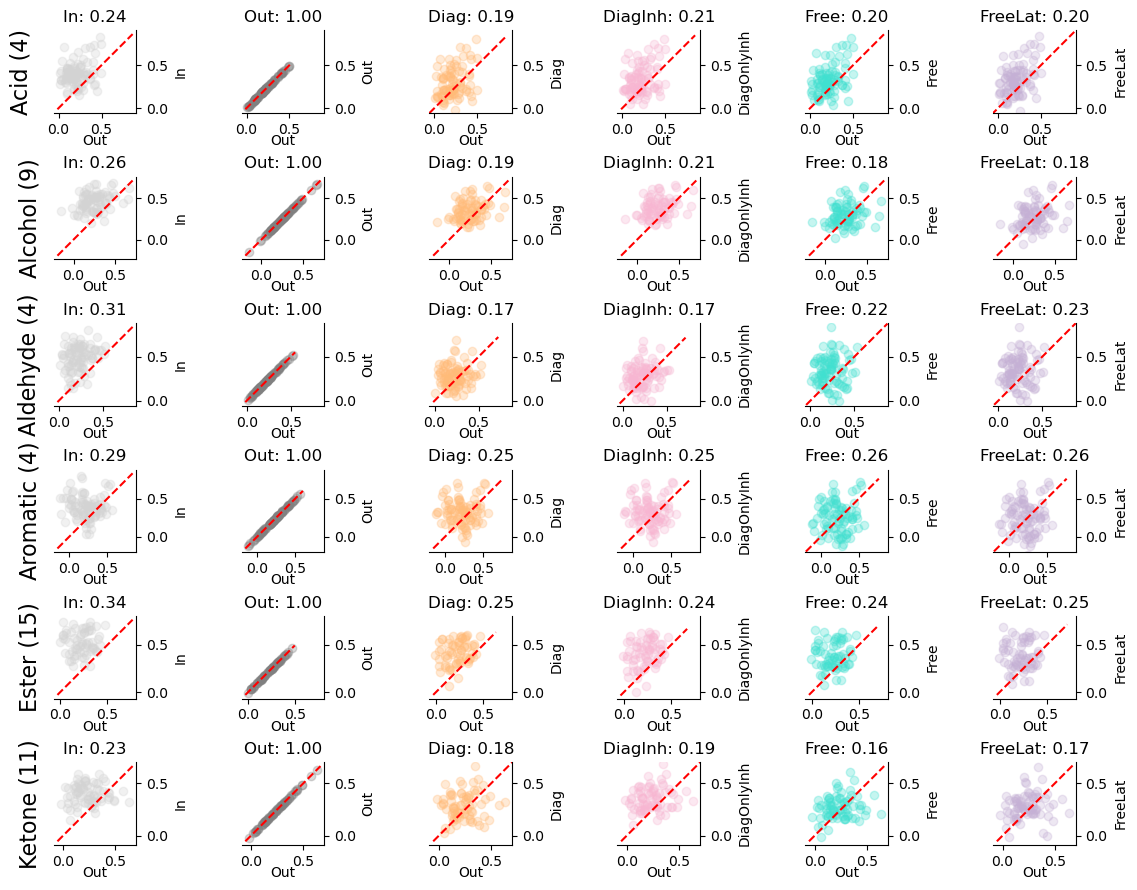

In [56]:
reload(results)
class_counts = Counter(odours.classes)
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
fig, ax = plt.subplots(nrows=6, ncols=2+len(which_models), figsize=(12, 9))
split = base.split(sampler="odours", mode="outclass", n_od_train="max")
for i, outclass in enumerate(outclasses): 
    extra_fields = {"outclass": outclass}
    for j, name in enumerate(which_models):
        model = split.model(name)
        res = model.extract(seed=0, train=0, metric=selection_metric, **extra_fields)
        covs = {k: getattr(res.vld, k) for k in ["Cin", "Cstar", "Cest"]}
        corrs = res.vld_corrs
        cov_in_out, cov_est_out = vld_fun_ratio(res.vld)
        corr_in_out, corr_est_out = vld_fun_corr(res.vld_corrs)
        corr_en_in, corr_en_out, corr_en_est = vld_fun_corr_energy(res.vld_corrs)
 
        vals = covs if prefix == "cov" else corrs
        plot_fun = lambda ax, k, ylab, c: scatter_plot(ax, vals["Cstar"], vals[k], "Out", ylab, c)

        in_val = {"cov":cov_in_out, "corr":corr_in_out, "corr_en":corr_en_in}[prefix]
        est_val = {"cov":cov_est_out, "corr":corr_est_out, "corr_en":corr_en_est}[prefix]
        out_val = {"cov":1., "corr":1., "corr_en":corr_en_out}[prefix]
 
        if name == "Diag":
            plot_fun(ax[i,0], "Cin", "In", "LightGray")
            append_to_title(ax[i,0], f": {in_val:.2f}")
            plot_fun(ax[i,1], "Cstar", "Out", "Gray")
            append_to_title(ax[i,1], f": {out_val:.2f}")
            plot_fun(ax[i,2], "Cest", "Diag", pfm.model_color("Diag"))
            append_to_title(ax[i,2], f": {est_val:.2f}")
        else:
            plot_fun(ax[i,2+j], "Cest", name, pfm.model_color(name))
            append_to_title(ax[i,2+j], f": {est_val:.2f}")
    
    [prepend_to_title(axi, ttl) for axi, ttl in zip(ax[i,:], ttls)]

    # Share the x and y lims with the first plot in the row
    for j in range(2 + len(which_models)):
        ax[i,j].set_xlim(ax[i,0].get_xlim())
        ax[i,j].set_ylim(ax[i,0].get_ylim())
        ax[i,j].set_aspect('equal')
        # Turn top and right spines off
        [ax[i,j].spines[spine].set_visible(False) for spine in ['top', 'left']]

    # Put the split description on the left of the row
    ax[i,0].text(-0.25 + 0.1*(i>0), 0.5, f"{outclass} ({class_counts[outclass]})", va='center', ha='right', 
                 fontsize=16, transform=ax[i,0].transAxes, rotation=90)
tight_layout(w_pad=0, h_pad=0.5)

## Compare Diag and DiagInh
These two models seem to give very similar performance on covariance, but quite different in terms of correlation. Let's understand why.

In [21]:
import layout; reload(layout)
import results; reload(results)
base = results.BaseContext(fits_root = proj_path + "/model-fitting/fits", models_dir=proj_path + "/model-fitting",
                          standardization="separate", normalization="odour_std", center=True)
split = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


In [133]:
from matplotlib.gridspec import GridSpec
def plot_comparison(models):
    n_mods = len(models)
    model_names = models.keys()
    fig = plt.figure(figsize=(4 * (2 + n_mods + 2), 8))
    gs = GridSpec(2, 2 + n_mods + 2)
    records = [] 
    ax_params = fig.add_subplot(gs[0,-3:])
    ax_hist = fig.add_subplot(gs[1,-3:])
    ax_cstar = [fig.add_subplot(gs[0,0]), fig.add_subplot(gs[1,0])]
    for i, (name, m) in enumerate(models.items()):
        ax = [fig.add_subplot(gs[0, i+1]), fig.add_subplot(gs[1, i+1])]
        if i == 0:
            # In the first row, do a matshow of Cstar, then of Cest (on the same scale), then a scatter plot of Cstar vs Cest
            vmin, vmax = percentile(m.vld.Cstar, [1, 99])
            ax_cstar[0].matshow(m.vld.Cstar, vmin=vmin, vmax=vmax, cmap="Spectral_r")
            ax_cstar[0].set_title("Cstar")
            ax_cstar[1].matshow(m.vld_corrs["Cstar"], vmin=0, vmax=1, cmap="bwr")
            ax_cstar[1].set_title("Rstar")
        
        ax[0].matshow(m.vld.Cest, vmin=vmin, vmax=vmax, cmap="Spectral_r")
        ax[0].set_title(f"Cest ({name})") 
        ratio = np.mean((m.vld.Cest - m.vld.Cstar)**2) / np.mean((m.vld.Cin - m.vld.Cstar)**2)
    
        ax[1].matshow(m.vld_corrs["Cest"], vmin=0, vmax=1, cmap="bwr")
        ax[1].set_title(f"Rest ({name})")

        ax_params.plot(m.params["p_final"], label=name, color=pfm.model_color(name))    
        ax_params.set_title("Final Parameters")
        ch = m.params["history"]["cov"] 
        ax_hist.semilogy(m.params["history"]["it"], ch, label=f"{name} (la = {m.la:1.1e}): {ch[-1]:.1f}", color=pfm.model_color(name))
        ax_hist.set_title("Covariance History")
        print(f"{name}: ")
        print(m.params["mdl.results"])

        corr_energy = compute_corr_energ_(m.vld_corrs["Cest"])
        records.append({"name": name, "ratio": ratio, "corr_energy": corr_energy})
    ax_params.legend()
    ax_hist.legend()

    return pd.DataFrame(records)

Diag: 
 message: Converged (|f_n-f_(n-1)| ~= 0)
 success: True
  status: 1
     fun: 365.3858622904408
       x: [ 2.178e-01  4.901e-01 ... -9.267e-01 -5.451e-01]
     nit: 34
     jac: [-4.692e-05  2.709e-05 ... -1.083e-06  1.294e-06]
    nfev: 326
DiagOnlyInh: 
 message: Converged (|f_n-f_(n-1)| ~= 0)
 success: True
  status: 1
     fun: 364.45672399379066
       x: [ 2.189e-01  4.872e-01 ... -1.117e+00 -6.189e-01]
     nit: 48
     jac: [-9.527e-05 -1.826e-04 ...  4.346e-06  2.290e-07]
    nfev: 305


,name,ratio,corr_energy
0,Diag,0.290996,0.108512
1,DiagOnlyInh,0.285680,0.109191


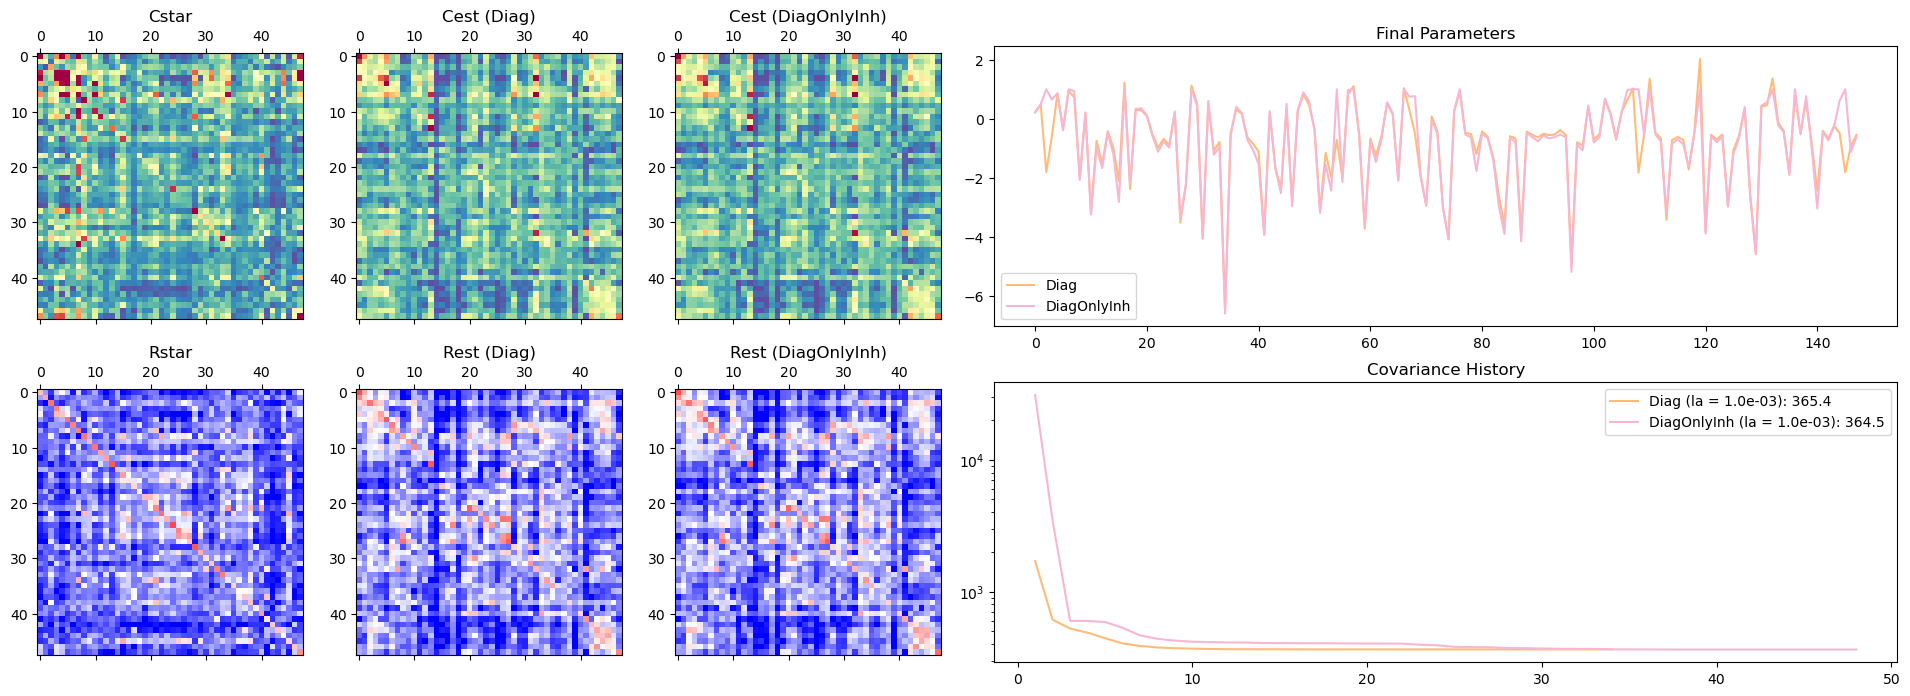

In [134]:
seed = 9
selection_metric = "ratio"
m_diag = split.model("Diag").extract(seed=seed, train=0, la = "min", metric=selection_metric, with_params = True)
m_diag_inh = split.model("DiagOnlyInh").extract(seed=seed, train=0, la = "min", metric=selection_metric, with_params=True)
plot_comparison({"Diag": m_diag, "DiagOnlyInh": m_diag_inh})

In [135]:
covs, corr_ens = [], []
covs_inh, corr_ens_inh = [], []
pfinals, pfinals_inh = [], []
for seed in range(50):
    res = split.model("DiagOnlyInh").extract(seed=seed, train=0, la = "min", metric=selection_metric, with_params=True)
    covs_inh.append(res.params["history"]["cov"][-1])
    corr_ens_inh.append(compute_corr_energ_(res.vld_corrs["Cest"]))
    pfinals_inh.append(res.params["p_final"])
    res = split.model("Diag").extract(seed=seed, train=0, la = "min", metric=selection_metric, with_params=True)
    covs.append(res.params["history"]["cov"][-1])
    corr_ens.append(compute_corr_energ_(res.vld_corrs["Cest"]))
    pfinals.append(res.params["p_final"])
pfinals = np.array(pfinals)
pfinals_inh = np.array(pfinals_inh)

Text(0.5, 1.0, 'Final Correlation Energy')

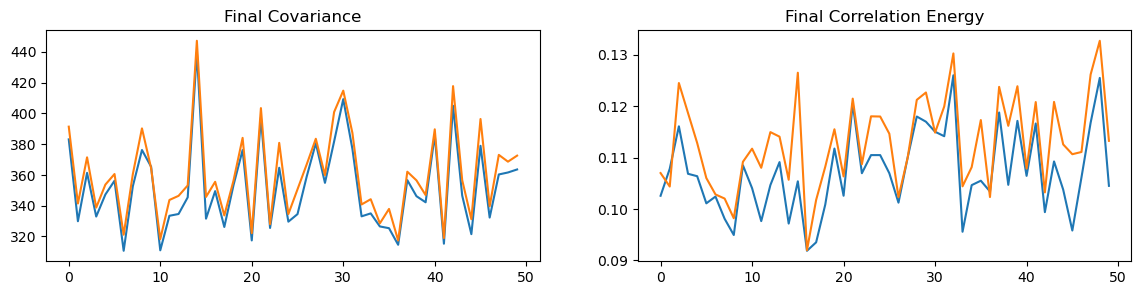

In [136]:
fig,ax = subplots(nrows=1, ncols=2, figsize=(14, 3))
ax[0].plot(covs); ax[0].plot(covs_inh); ax[0].set_title("Final Covariance")
ax[1].plot(corr_ens); ax[1].plot(corr_ens_inh); ax[1].set_title("Final Correlation Energy")

### Compare solutions

In [55]:
def plot_pfinals(pfinals, covs):
    u,s,v = np.linalg.svd(pfinals, full_matrices=False)
    c = u @ np.diag(s)
    iord = np.argsort(c[:,0]).astype(int)
    fig, ax = plt.subplots(figsize=(14,5))
    ax.matshow(pfinals[iord,:], vmin=-5, vmax=5, cmap="bwr")
    ax.set_yticks(np.arange(len(iord)), labels=iord, fontsize=6);
    ax.set_xlabel("Input Channel")
    ax1 = ax.twiny()
    ax1.plot(np.array(covs)[iord], np.arange(len(iord)), '-')
    ax1.set_xlabel("Final Covariance")
    return fig, ax, ax1, c[:,0]

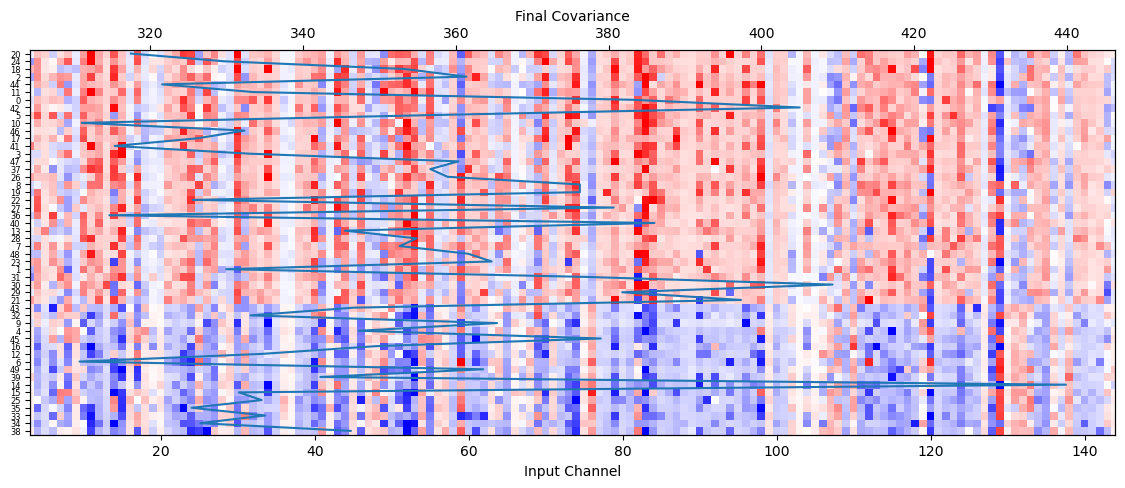

In [56]:
fig, ax, xa1, c = plot_pfinals(pfinals, covs) 

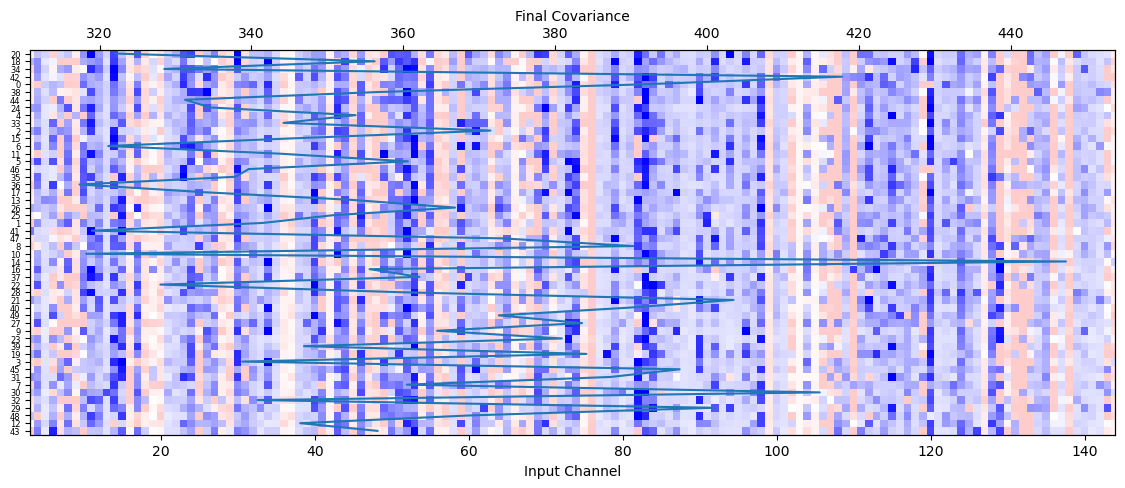

In [48]:
fig, ax, ax1, c = plot_pfinals(pfinals_inh, covs_inh)

### Let's run seed 9 manually
Perhaps poor results were due to (too) early exit.

In [58]:
trials = base.split(sampler="trials", mode="random", n_od_train="max")

Loaded split models from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/loaded_models.p.


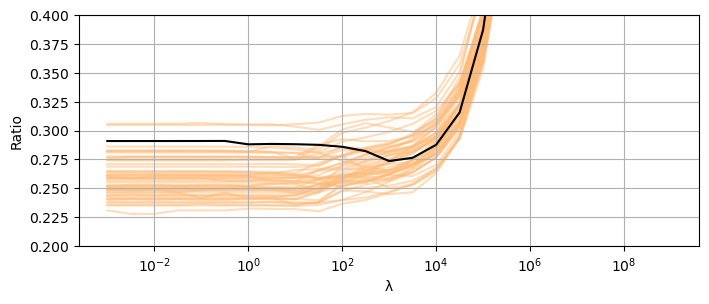

In [59]:
# Plot the test ratio for seeds
mdl = "DiagOnlyInh"
mdl = "Diag"
df = trials.loaded_models[mdl]["df"]
seeds = df["seed"].unique()
for i in sorted(seeds):
    df_sub = df[(df.seed == i) & (df.split=="vld") & (df.ref=="train[0]")].sort_values("λ")
    la = df_sub["λ"]
    ratio = df_sub["ratio"]
    semilogx(la, ratio, '-', color=pfm.model_color(mdl) if i != 9 else "k", alpha=0.5 if i != 9 else 1, label=f"seed {i}", zorder=1 if i != 9 else 2)
xlabel("λ")
ylabel("Ratio")
ylim(0.2,0.4)
grid(True)


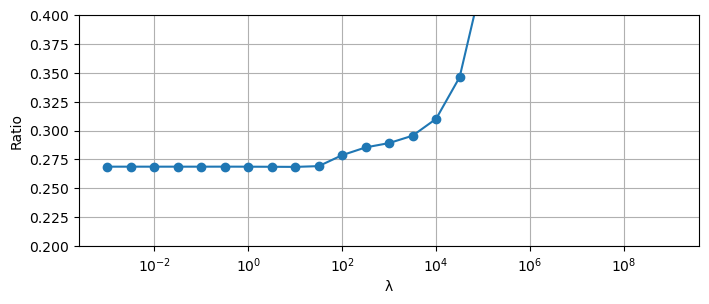

In [60]:
df_sub = df_sub.sort_values("λ")
la = df_sub["λ"]
rato = df_sub["ratio"]
semilogx(la, rato, 'o-')
ylim(0.2,0.4)
xlabel("λ")
ylabel("Ratio")
grid(True)

In [61]:
# Manually run in.225.p
with open(os.path.join(trials.split_dir, "fit_diag", "in.237.p"), "rb") as f:
    inp = pickle.load(f)
results = driver.run(inp)

Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[20, 42, 7, 38, 15, 32, 39, 26, 4, 25, 2, 14, 35, 36, 34, 21, 41, 30, 13, 8, 17, 16, 9, 23, 6, 19, 5, 11, 3, 31, 45, 37, 44, 18, 12, 43, 10, 24, 0, 47, 29, 33, 27, 40, 46, 1, 22, 28]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[20, 42, 7, 38, 15, 32, 39, 26, 4, 25, 2, 14, 35, 36, 34, 21, 41, 30, 13, 8, 17, 16, 9, 23, 6, 19, 5, 11, 3, 31, 45, 37, 44, 18, 12, 43, 10, 24, 0, 47, 29, 33, 27, 40, 46, 1, 22, 28]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
init_args={'center': True, 'λ': np.float64(1000.0)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
Running minimization with 2

# Free Model

In [430]:
sys.path.append(os.path.join(git_path))
from label_axes.label_axes import label_axes
# Get row and col order of given W by hierarchical clustering of the rows and columns of W
from scipy.cluster.hierarchy import linkage, leaves_list
def get_row_col_order(W, method='ward'):
    # Compute the linkage for rows and columns
    row_linkage = linkage(W, method=method)
    col_linkage = linkage(W.T, method=method)

    # Get the order of rows and columns based on the clustering
    row_order = leaves_list(row_linkage)
    col_order = leaves_list(col_linkage)

    return row_order, col_order

In [146]:
import conn_models; reload(conn_models); from conn_models import free as free_model
reload(free_model); from conn_models import free_lat as free_lat_model; reload(free_lat_model)

<module 'conn_models.free_lat' from '/nemo/lab/schaefera/working/tootoos/git/glom-io-transform-release/model-fitting/conn_models/free_lat.py'>

Free: 
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 361.52592338536886
        x: [ 6.358e-01 -5.745e-02 ... -3.903e-04  1.003e+00]
      nit: 90
      jac: [-2.125e-02 -2.332e-02 ... -5.630e-04  4.348e-05]
     nfev: 93
     njev: 93
 hess_inv: <21904x21904 LbfgsInvHessProduct with dtype=float64>
FreeLat: 
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 380.76141976821935
        x: [ 9.218e-01  5.744e-01 ...  3.875e-04  2.411e-02]
      nit: 560
      jac: [ 8.567e-03  1.960e-02 ... -8.735e-03 -3.415e-03]
     nfev: 597
     njev: 597
 hess_inv: <21756x21756 LbfgsInvHessProduct with dtype=float64>


,name,ratio,corr_energy
0,Free,0.210860,0.131538
1,FreeLat,0.211004,0.134149


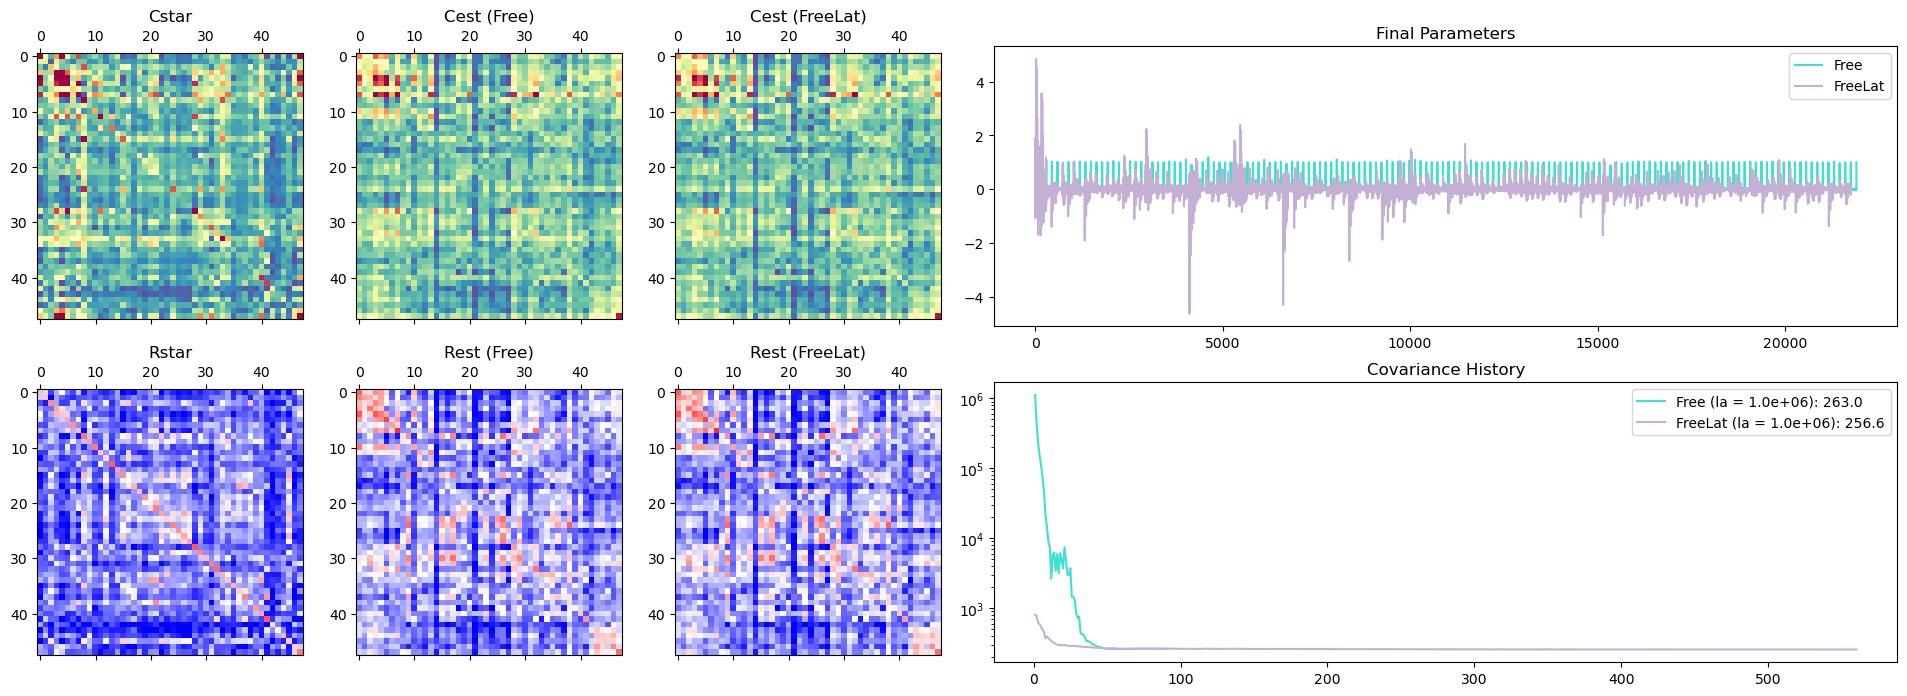

In [326]:
seed = 30
selection_metric = "r2"
m_free = split.model("Free").extract(seed=seed, train=0, la = None, metric=selection_metric, with_params = True)
m_free_lat = split.model("FreeLat").extract(seed=seed, train=0, la = None, metric=selection_metric, with_params=True)
plot_comparison({"Free": m_free, "FreeLat": m_free_lat})

In [415]:
Zfree = free_model.Model._ZFUN(m_free.params["p_final"])
Wfree = np.linalg.inv(Zfree) - np.eye(Zfree.shape[0])
Wlat = free_lat_model.Model._WFUN(m_free_lat.params["p_final"])
m = Wlat.shape[0]; Zlat = np.linalg.inv(np.eye(m) + Wlat)

(A) The estimated solutions are very similar.

(B) The effective feedforward solutions $Z$ are similar.

(C) The effective recufrrent solutions $W$ are different


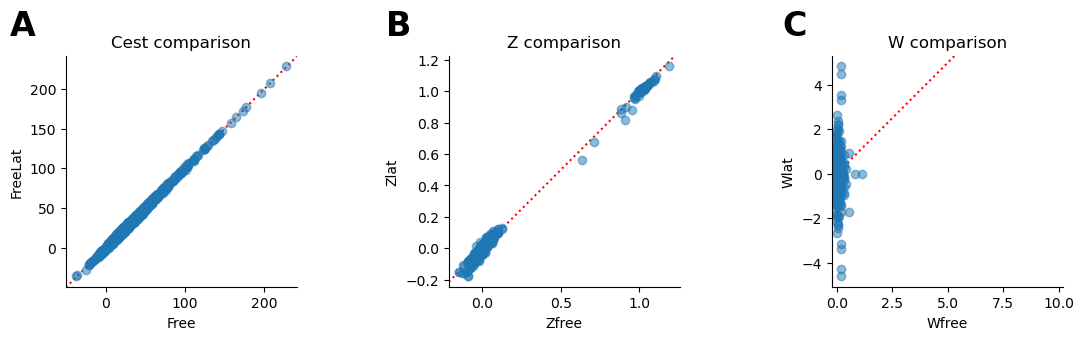

In [422]:
fig, ax = subplots(nrows=1, ncols=3, figsize=(14, 3))
ax[0].plot(m_free.vld.Cest.flatten(), m_free_lat.vld.Cest.flatten(), 'o', alpha=0.5); ax[0].axis('square'); ax[0].set_xlabel("Free"); ax[0].set_ylabel("FreeLat"); ax[0].set_title("Cest comparison")
ax[0].plot(ax[0].get_xlim(), ax[0].get_xlim(), 'r:', zorder=0)
ax[1].plot(Zfree.flatten(), Zlat.flatten(), 'o', alpha=0.5); ax[1].axis('square'); ax[1].set_xlabel("Zfree"); ax[1].set_ylabel("Zlat"); ax[1].set_title("Z comparison")
ax[1].plot(ax[1].get_xlim(), ax[1].get_xlim(), 'r:', zorder=0)
ax[2].plot(Wfree.flatten(), Wlat.flatten(), 'o', alpha=0.5); ax[2].axis('square'); ax[2].set_xlabel("Wfree"); ax[2].set_ylabel("Wlat"); ax[2].set_title("W comparison")
ax[2].plot(ax[2].get_xlim(), ax[2].get_xlim(), 'r:', zorder=0)
# Turn top and right spines off
[axi.spines[spine].set_visible(False) for axi in ax for spine in ['top', 'right']]
label_axes(ax, labs=list("ABC"), fontsize=24, fontweight="bold") 

The connectivity solutions agree from about the third mode on:

In [424]:
U, s, Vt = np.linalg.svd(no_diag(Wfree)); rord = argsort(U[:,0]); cord = argsort(Vt[0,:])
Ul, sl, Vtl = np.linalg.svd(Wlat); rord_l = argsort(Ul[:,0]); cord_l = argsort(Vtl[0,:])

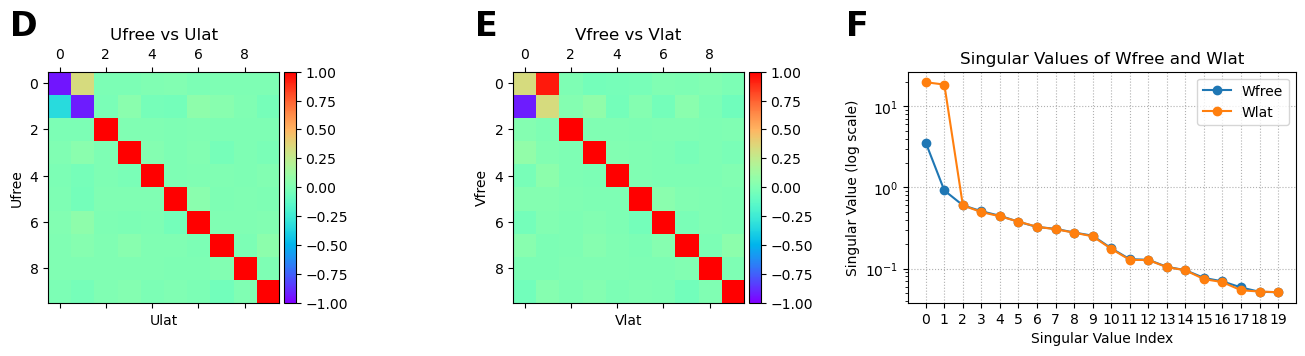

In [448]:
cm_name = "rainbow"
fig, ax = subplots(nrows=1, ncols=3, figsize=(17, 3))
ax[0].matshow((U.T @ Ul)[:10,:10], cmap=cm_name, vmin=-1, vmax=1); ax[0].set_title("Ufree vs Ulat"); ax[0].set_xlabel("Ulat"); ax[0].set_ylabel("Ufree")
ax[1].matshow((Vt @ Vtl.T)[:10,:10], cmap=cm_name, vmin=-1, vmax=1); ax[1].set_title("Vfree vs Vlat"); ax[1].set_xlabel("Vlat"); ax[1].set_ylabel("Vfree")
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax[0]); cax = divider.append_axes("right", size="5%", pad=0.05); fig.colorbar(cm.ScalarMappable(cmap=cm_name, norm=Normalize(vmin=-1, vmax=1)), cax=cax, orientation="vertical")
divider = make_axes_locatable(ax[1]); cax = divider.append_axes("right", size="5%", pad=0.05); fig.colorbar(cm.ScalarMappable(cmap=cm_name, norm=Normalize(vmin=-1, vmax=1)), cax=cax, orientation="vertical")
ax[2].semilogy(s[:20], "o-", label="Wfree"); ax[2].plot(sl[:20], "o-",label="Wlat"); ax[2].set_xlabel("Singular Value Index"); ax[2].set_ylabel("Singular Value (log scale)")
ax[2].set_xticks(np.arange(0, 20, 1)); ax[2].set_title("Singular Values of Wfree and Wlat"); ax[2].legend(); ax[2].grid(True, linestyle=":")
label_axes(ax, labs=list("DEF"), fontsize=24, fontweight="bold", align_y =[[0,1,2]])

There is agreement until the noise floor.

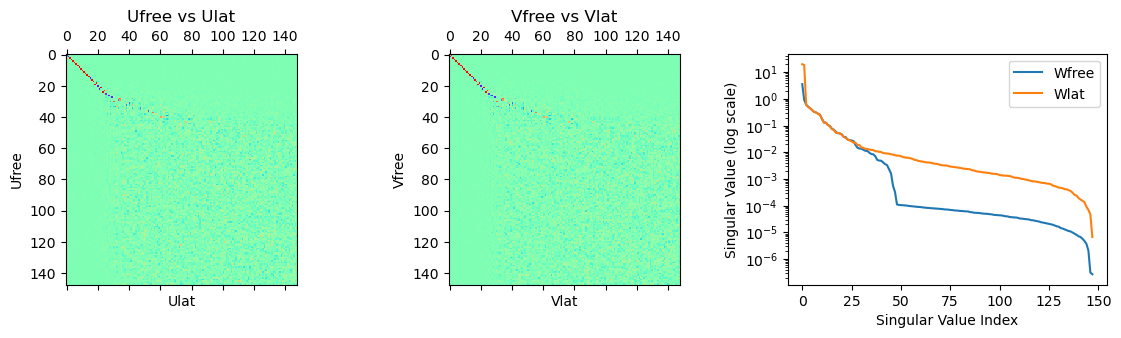

In [435]:
fig, ax = subplots(nrows=1, ncols=3, figsize=(14, 3))
ax[0].matshow((U.T @ Ul), cmap=cm_name, vmin=-1, vmax=1); ax[0].set_title("Ufree vs Ulat"); ax[0].set_xlabel("Ulat"); ax[0].set_ylabel("Ufree")
ax[1].matshow((Vt @ Vtl.T), cmap=cm_name, vmin=-1, vmax=1); ax[1].set_title("Vfree vs Vlat"); ax[1].set_xlabel("Vlat"); ax[1].set_ylabel("Vfree")
ax[2].semilogy(s, label="Wfree"); ax[2].plot(sl, label="Wlat"); ax[2].set_xlabel("Singular Value Index"); ax[2].set_ylabel("Singular Value (log scale)"); ax[2].legend()

The solution for the lower modes is symmetric for both. The upper modes are symmetric in Free, antisymmetric in Lat.

In [436]:
irest = 2
Wfree_head = U[:, :irest] @ np.diag(s[:irest]) @ Vt[:irest, :]
Wlat_head = Ul[:, :irest] @ np.diag(sl[:irest]) @ Vtl[:irest, :]
Wfree_rest = U[:, irest:] @ np.diag(s[irest:]) @ Vt[irest:, :]
Wlat_rest = Ul[:, irest:] @ np.diag(sl[irest:]) @ Vtl[irest:, :]

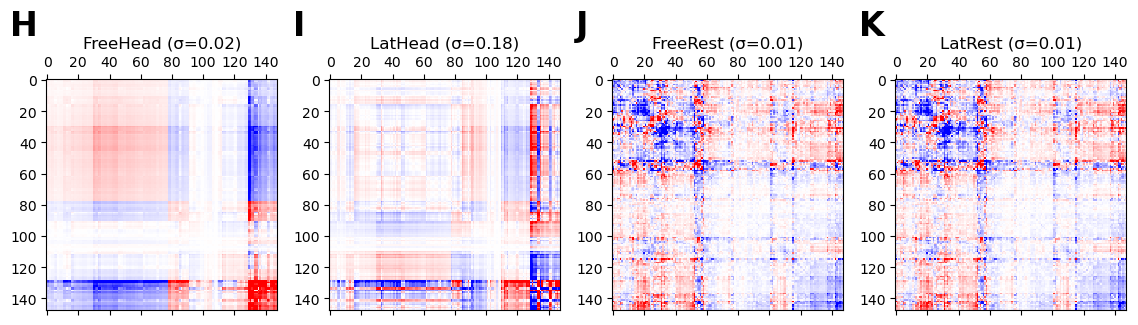

In [449]:
W = {"FreeHead": Wfree_head, "FreeRest": Wfree_rest, "LatHead": Wlat_head, "LatRest": Wlat_rest}
row_order = {name: get_row_col_order(W[name])[0] for name in plot_order}
plot_order = ["FreeHead", "LatHead", "FreeRest", "LatRest"]
fig, ax = subplots(nrows=1, ncols=4, figsize=(14, 3))
for i, name in enumerate(plot_order):
    axi = ax[i]
    rord = row_order["FreeHead"] if "Head" in name else row_order["FreeRest"]
    vlim = 3 * W[name].std()
    matshow_kwargs = {"vmin": -vlim, "vmax": vlim, "cmap": "bwr"}
    axi.matshow(W[name][rord, :][:, rord], **matshow_kwargs)
    axi.set_title(f"{name} (σ={W[name].std():.2f})")
label_axes(ax, labs=list("HIJK"), fontsize=24, fontweight="bold", align_y =[[0,1,2,3]])

# Older stuff

In [342]:
res = split.model("DiagOnlyInh")
in_file = os.path.join(res.base_dir, "in.0.p")
assert os.path.exists(in_file), f"Input file {in_file} does not exist"
with open(in_file, "rb") as f:
    in_data = pickle.load(f)

In [343]:
in_data["min_args"]["p_init"]

'[(i,1e-3) for i in range(-2,3)] * 3'

In [402]:
out_file = in_file.replace("in.0.p", "out.0.p").replace("fit_diag__inh_only", "ffree_lat")
print(f"Output file: {out_file}")
with open(out_file, "rb") as f:
    out_data = pickle.load(f)

Output file: /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/ffree_lat/out.0.p


0: p0 = -0.20001422837620006
1: p0 = -0.10005335711752633
2: p0 = -5.290545440230701e-05
3: p0 = 0.10007776567079156
4: p0 = 0.20017101214682098
5: p0 = -0.19993538524950902
6: p0 = -0.0998600755258613
7: p0 = 2.390491847695129e-05
8: p0 = 0.09996629018988241
9: p0 = 0.19999579131184728


(0.0, 100.0)

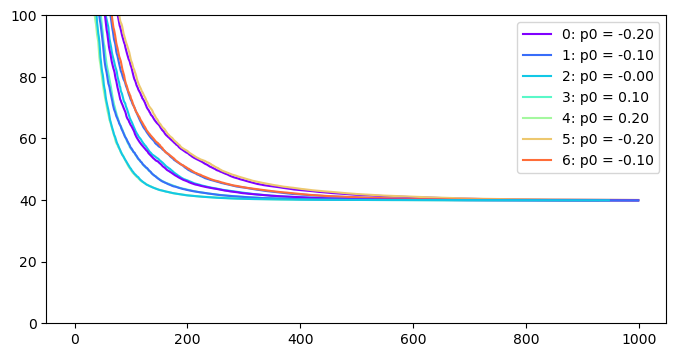

In [403]:
figure(figsize=(8, 4))
for i, run in enumerate(out_data["results"]["all_runs"]):
    p0 = run["p0"]
    print(f"{i}: p0 = {p0.mean()}")
    h = run["history"]
    plot(h["f"], color = cm.rainbow((i % 7)/7.), label = f"{i}: p0 = {p0.mean():.2f}" if i < 7 else None)
legend()
ylim(0,100)


In [344]:
res_ex = res.extract(seed=0, train=0, metric=selection_metric, with_params=True)

In [349]:
res._file_cache.keys()

dict_keys(['out.5.p'])

In [347]:
in_file

'/camp/home/tootoos/working/tootoos/git/glom-io-transform-release/model-fitting/fits/center=True/standardization=separate/normalization=odour_std/sampler=trials/mode=random/n_od_train=max/fit_diag__inh_only/in.0.p'

In [346]:
res_ex.params.keys()

dict_keys(['p_init', 'p_final', 'mdl.results', 'history'])

In [338]:
in_data["min_args"]["p0"] = -1 + 0*pfinals_inh[9] + 0.001 * np.random.randn(*pfinals_inh[9].shape) 
results = driver.run(in_data)

Loading data from /camp/home/tootoos/working/tootoos/git/glom-io-transform-release/data/X0Y0_new.p
Assembling INPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by odour.
Assembling OUTPUTS.
Generating splits with TrialsSampler, n_train=10, train_odours=[33, 23, 38, 36, 2, 3, 31, 26, 44, 27, 28, 47, 21, 34, 19, 40, 35, 24, 22, 13, 39, 17, 46, 4, 29, 14, 10, 42, 32, 18, 41, 30, 20, 25, 6, 7, 45, 1, 16, 0, 15, 5, 11, 9, 8, 12, 43, 37]
Materializing split...
Standardizing training, test and validation sets separately.
Normalizing by overall standard deviation.
init_args={'center': True, 'λ': np.float64(0.001)}
Regularizing z**1 - 1
bounds (-inf, inf)
Running model...
RUNNING MINIMIZATION using m

In [339]:
res_ex = res.extract(seed=1, train=0, metric="ratio", with_params=True)

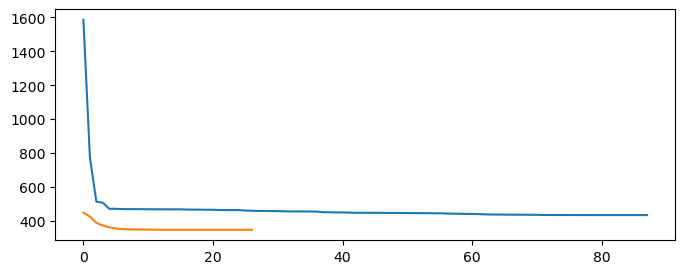

In [340]:
plot(res_ex.params["history"]["cov"])
plot(results["history"]["cov"][2:])

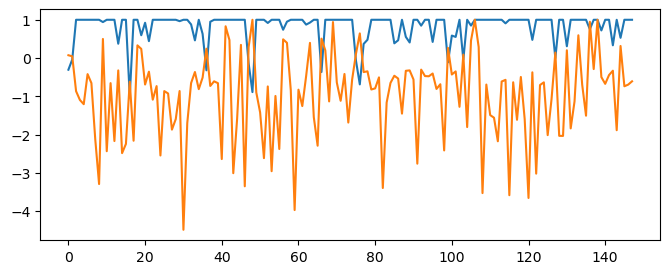

In [341]:
plot(res_ex.params["p_final"])
plot(results["p_final"])

In [337]:
results["history"]["cov"][-1], res_ex.params["history"]["cov"][-1]

(np.float64(346.75487399856837), np.float64(435.75540838694))